# 01 — Data Exploration & Preprocessing

## Adult Census Income Dataset (UCI)

This notebook explores the Adult Census dataset and applies the preprocessing pipeline that prepares the data for CTGAN training.

**Key decisions documented here:**
1. Handling of missing values encoded as `'?'`
2. Removal of `fnlwgt` (sampling weight, not an individual attribute)
3. Stratified sampling for tractable training while preserving class balance
4. Holdout reservation for unbiased TSTR evaluation

**Dataset reference:** Becker, B., & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Auto-detect project root by searching upward for src/config.py
current = Path.cwd()
while current != current.parent:
    if (current / "src" / "config.py").exists():
        project_root = current
        break
    current = current.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    ADULT_CSV_PATH,
    CATEGORICAL_COLUMNS,
    CONTINUOUS_COLUMNS,
    TARGET_COLUMN,
    TRAIN_SAMPLE_SIZE,
)
from src.preprocessing import (
    load_adult_dataset,
    report_missing_values,
    clean_dataset,
    stratified_train_holdout_split,
)

print(f"Project root: {project_root}")
print(f"Dataset: {ADULT_CSV_PATH.name}")

Project root: c:\Users\Jorge alberto\Documents\Universidades\UNIR\PSU - IA Generativa aplicada a Data\Actividad 1\Codigo Actividad\ctgan-adult-critical-evaluation
Dataset: adult.csv


## 2. Load Raw Dataset

We load the raw CSV and inspect its dimensions and column types. The dataset contains demographic and employment information from the 1994 U.S. Census, with 32,561 records and 15 columns including a binary income target.

In [2]:
df_raw = load_adult_dataset()
print(f"Shape: {df_raw.shape}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Shape: (32561, 15)

Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


In [3]:
df_raw.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### Target distribution

The target variable `income` is binary and **imbalanced**: roughly 76% of records correspond to individuals earning ≤50K USD/year and 24% to >50K. This imbalance is preserved through stratified sampling later in the pipeline and matters for downstream classification metrics (notably F1 over accuracy).

In [4]:
target_dist = df_raw[TARGET_COLUMN].value_counts(normalize=True).round(4)
print(f"Target ({TARGET_COLUMN}) distribution:")
print(target_dist)
print(f"\nImbalance ratio: {target_dist.iloc[0] / target_dist.iloc[1]:.2f} : 1")

Target (income) distribution:
income
<=50K    0.7592
>50K     0.2408
Name: proportion, dtype: float64

Imbalance ratio: 3.15 : 1


## 3. Missing Value Detection

Adult Census uses `'?'` as the marker for missing values rather than `NaN`. Standard `pandas.isnull()` will not detect these. We use a custom function that scans object-dtype columns for the marker.

In [6]:
missing_report = report_missing_values(df_raw)
print("Columns with missing values (encoded as '?'):")
print(missing_report.to_string(index=False))

total_affected = missing_report["missing_count"].sum()
print(f"\nTotal cells with missing values: {total_affected}")
print(f"Approximate rows affected (worst case): {total_affected}")

Columns with missing values (encoded as '?'):
        column  missing_count  missing_pct
     workclass           1836         5.64
    occupation           1843         5.66
native.country            583         1.79

Total cells with missing values: 4262
Approximate rows affected (worst case): 4262


**Decision: drop affected rows.**

We considered three approaches:

1. **Recode `'?'` as `'Unknown'`** — preserves all rows but introduces an artificial category that CTGAN would model as legitimate.
2. **GAN-based imputation (GAIN)** — methodologically rich but adds a second adversarial model that confounds attribution: if final synthetic quality is low, was it the imputation or the generation?
3. **Drop rows with `'?'`** — loses ~7.4% of data but keeps the experiment focused on CTGAN's behavior.

We choose option 3 because it matches the original CTGAN paper's preprocessing (Xu et al., 2019) and preserves analytical clarity. GAIN is documented in the README as future work.

## 4. Zero-Inflated Variables: A Critical Diagnostic

Two continuous variables in this dataset have an unusual distributional structure: `capital.gain` and `capital.loss`. Both are **zero-inflated with heavy positive tails** — a single value (zero) accumulates the vast majority of observations, while the remaining mass is spread across a wide positive range.

This pattern is common in real-world tabular data:
- **Healthcare**: hospital length of stay (most patients = 0, few = very long)
- **E-commerce**: refund amount (most customers = 0, few = high)
- **Insurance**: claim amount (most policyholders = 0, few = catastrophic)
- **Finance**: days past due (most accounts = 0, few = severely delinquent)

We diagnose this structure now because it determines a key design decision in V2 of our experiment.

In [7]:
zero_inflated_diagnostics = []
for col in ["capital.gain", "capital.loss"]:
    pct_zero = (df_raw[col] == 0).mean() * 100
    nonzero = df_raw[col][df_raw[col] > 0]
    zero_inflated_diagnostics.append({
        "variable": col,
        "pct_zero": round(pct_zero, 2),
        "min_nonzero": int(nonzero.min()) if len(nonzero) > 0 else 0,
        "max": int(df_raw[col].max()),
        "mean_nonzero": round(nonzero.mean(), 2) if len(nonzero) > 0 else 0,
        "n_unique_nonzero": nonzero.nunique(),
    })

diagnostics_df = pd.DataFrame(zero_inflated_diagnostics)
print("Zero-inflation diagnostics:")
print(diagnostics_df.to_string(index=False))

Zero-inflation diagnostics:
    variable  pct_zero  min_nonzero   max  mean_nonzero  n_unique_nonzero
capital.gain     91.67          114 99999      12938.54               118
capital.loss     95.33          155  4356       1871.43                91


### Visual confirmation

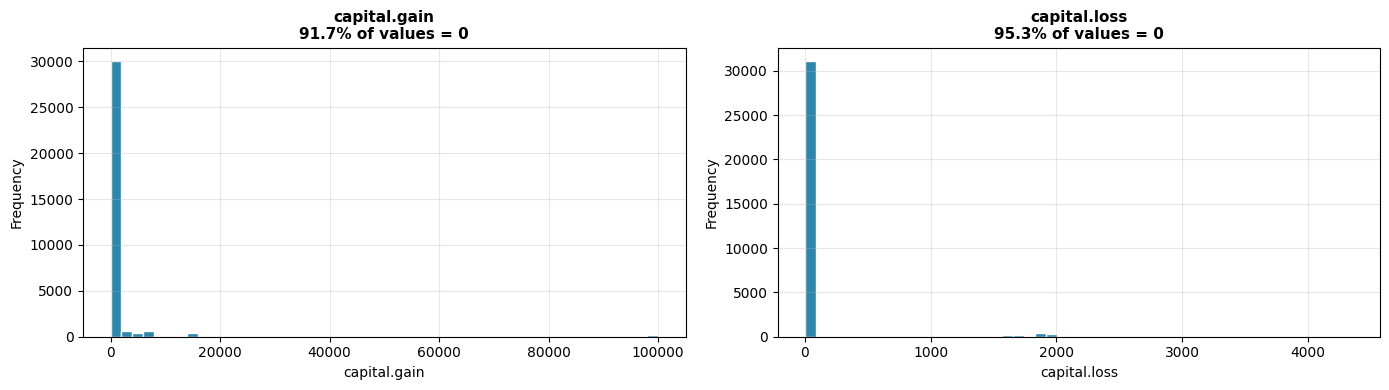

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, col in enumerate(["capital.gain", "capital.loss"]):
    axes[i].hist(df_raw[col], bins=50, color="#2E86AB", edgecolor="white")
    pct_zero = (df_raw[col] == 0).mean() * 100
    axes[i].set_title(f"{col}\n{pct_zero:.1f}% of values = 0", fontsize=11, weight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Why this matters for CTGAN.**

CTGAN models continuous variables using **Mode-Specific Normalization** based on Variational Gaussian Mixtures (VGM). This works well for multimodal continuous distributions — but **degenerates for point masses**. The VGM cannot represent a Dirac delta at zero; it must approximate it with narrow Gaussian components, which inevitably produce nearby non-zero values when sampled.

This is the structural limitation that motivates V2 of our experiment, where we apply `log1p` transformation to compress the heavy tail before training, then invert with `expm1` and clip to zero after generation.

## 5. Categorical Cardinality

Categorical variables vary widely in cardinality, from binary (`sex`, `income`) to high-cardinality (`native.country` with 41 distinct values). This asymmetry matters for CTGAN's **Conditional Sampling** mechanism, which is specifically designed to prevent the generator from collapsing toward majority categories.

In [10]:
cat_diagnostics = []
for col in df_raw.select_dtypes(include="object").columns:
    n_unique = df_raw[col].nunique()
    top_cat = df_raw[col].mode().iloc[0]
    top_pct = (df_raw[col] == top_cat).mean() * 100
    cat_diagnostics.append({
        "variable": col,
        "cardinality": n_unique,
        "top_category": top_cat,
        "top_pct": round(top_pct, 2),
    })

cat_df = pd.DataFrame(cat_diagnostics).sort_values("cardinality", ascending=False)
print("Categorical variables — cardinality and dominant category:")
print(cat_df.to_string(index=False))

Categorical variables — cardinality and dominant category:
      variable  cardinality       top_category  top_pct
native.country           42      United-States    89.59
     education           16            HS-grad    32.25
    occupation           15     Prof-specialty    12.71
     workclass            9            Private    69.70
marital.status            7 Married-civ-spouse    45.99
  relationship            6            Husband    40.52
          race            5              White    85.43
           sex            2               Male    66.92
        income            2              <=50K    75.92


**`native.country` is the critical case.** With 41 categories and `United-States` accounting for ~90% of records, this is the variable where Conditional Sampling earns its keep. Without it, the generator would suffer **mode collapse** — emitting `United-States` for nearly every synthetic sample and effectively erasing the diversity of minority countries.

We will validate this empirically in the V1 evaluation notebook by checking JSD on `native.country`.

## 6. Apply Preprocessing Pipeline

We now run the full preprocessing pipeline:

1. **Replace `'?'` with `NaN`** and drop affected rows
2. **Drop `fnlwgt`** (Census sampling weight, not an individual attribute — its preservation in synthetic data has no semantic meaning)
3. **Stratified sample of 10,000 rows** for training, preserving the 76/24 income distribution
4. **Reserve the remaining ~20,000 rows as holdout** for unbiased TSTR evaluation

The split is deterministic (fixed `random_state=42`) for reproducibility.

In [11]:
df_clean = clean_dataset(df_raw)

rows_dropped = df_raw.shape[0] - df_clean.shape[0]
pct_dropped = rows_dropped / df_raw.shape[0] * 100
print(f"After cleaning:")
print(f"  Shape: {df_clean.shape}")
print(f"  Rows dropped: {rows_dropped} ({pct_dropped:.2f}%)")
print(f"  Columns dropped: ['fnlwgt']")

After cleaning:
  Shape: (30162, 14)
  Rows dropped: 2399 (7.37%)
  Columns dropped: ['fnlwgt']


In [12]:
df_train, df_holdout = stratified_train_holdout_split(df_clean)

print(f"Train (for CTGAN):  {df_train.shape}")
print(f"Holdout (for TSTR): {df_holdout.shape}")

train_dist = df_train[TARGET_COLUMN].value_counts(normalize=True).round(4).to_dict()
holdout_dist = df_holdout[TARGET_COLUMN].value_counts(normalize=True).round(4).to_dict()

print(f"\nIncome distribution preserved:")
print(f"  Train:   {train_dist}")
print(f"  Holdout: {holdout_dist}")

Train (for CTGAN):  (10000, 14)
Holdout (for TSTR): (20162, 14)

Income distribution preserved:
  Train:   {'<=50K': 0.7511, '>50K': 0.2489}
  Holdout: {'<=50K': 0.7511, '>50K': 0.2489}


## 7. Summary

| Metric | Value |
|---|---|
| Original dataset | 32,561 × 15 |
| After cleaning | 30,162 × 14 |
| Train set (used for CTGAN) | 10,000 × 14 |
| Holdout (used for TSTR) | 20,162 × 14 |
| Categorical columns | 9 (incl. target) |
| Continuous columns | 5 |
| Zero-inflated variables flagged | `capital.gain`, `capital.loss` |
| Imbalance ratio in target | 3.15 : 1 |

These splits are persisted to `results/v1_baseline/` and consumed by the training script (`run_training.py`) and downstream evaluation notebooks.

## 8. Persistence Confirmation

The training script `run_training.py` already executed the same pipeline and persisted the resulting splits to disk. We verify they exist and match what we computed here.

In [13]:
from src.config import V1_DIR

train_path = V1_DIR / "real_train.csv"
holdout_path = V1_DIR / "real_holdout.csv"

print(f"Persisted files in {V1_DIR}:")
for path in [train_path, holdout_path]:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        n_rows = sum(1 for _ in open(path)) - 1  # subtract header
        print(f"  ✓ {path.name}: {n_rows:,} rows ({size_kb:,.1f} KB)")
    else:
        print(f"  ✗ {path.name}: NOT FOUND — run `python run_training.py` first")

Persisted files in c:\Users\Jorge alberto\Documents\Universidades\UNIR\PSU - IA Generativa aplicada a Data\Actividad 1\Codigo Actividad\ctgan-adult-critical-evaluation\results\v1_baseline:
  ✓ real_train.csv: 10,000 rows (1,011.2 KB)
  ✓ real_holdout.csv: 20,162 rows (2,038.1 KB)


---

**Notebook 1 complete.** The dataset is cleaned, split, and persisted. The next notebooks consume these artifacts:

- **`02_baseline_v1.ipynb`** — evaluates the V1 CTGAN (no log transform) using five metrics
- **`03_improved_v2.ipynb`** — evaluates the V2 CTGAN (with `log1p` on zero-inflated variables) and compares against V1